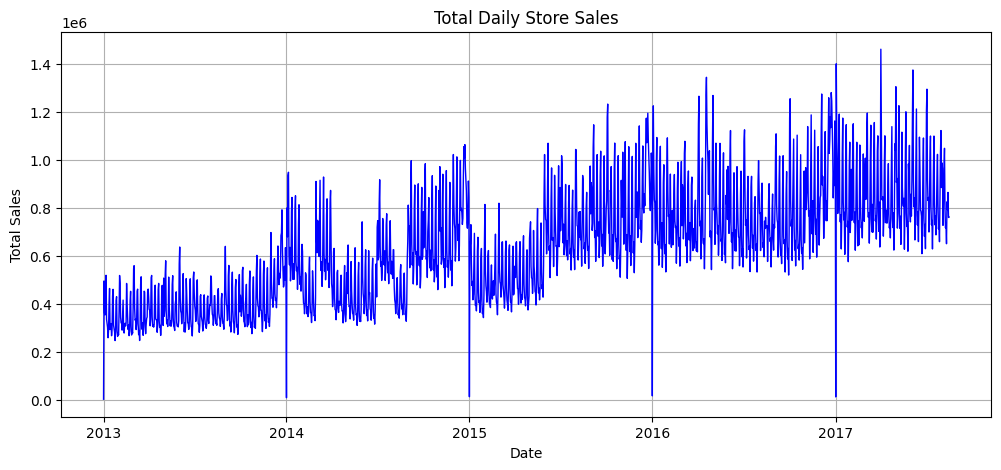

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Read real data downloaded from Kaggle
# included：id, date, store_nbr, family, sales, onpromotion
train = pd.read_csv('train.csv', parse_dates=['date'])

# 2. Aggregate total store sales by date 
daily_sales = train.groupby('date')['sales'].sum().to_frame()

# 3. plot total daily store sales time series pigture
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales['sales'], color='blue', linewidth=1)
plt.title("Total Daily Store Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


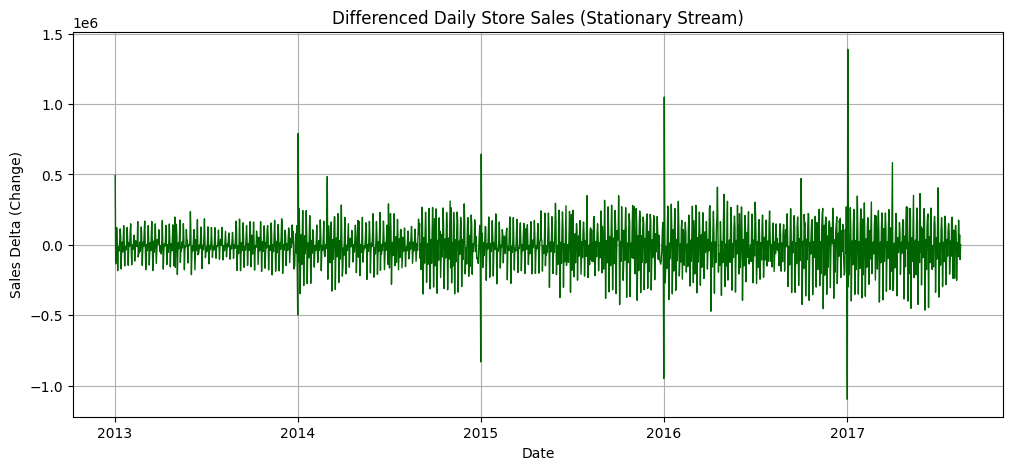

In [6]:
# 1. Subtract yesterday sales from today sales
daily_sales['sales_diff'] = daily_sales['sales'].diff()

# 2. Drop the first day NaN data
cleaned_df = daily_sales.dropna()

# 3. Plot differenced daily store sales
plt.figure(figsize=(12, 5))
plt.plot(cleaned_df.index, cleaned_df['sales_diff'], color='darkgreen', linewidth=1)

plt.title("Differenced Daily Store Sales (Stationary Stream)")
plt.xlabel("Date")
plt.ylabel("Sales Delta (Change)")
plt.grid(True)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller
train = pd.read_csv('train.csv')

#Do ADF test and get the P-value
sample_series = train.groupby('date')['sales'].sum() 

result = adfuller(sample_series)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"Exact p-value: {result[1]:.4e}") 
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.4f}")

ADF Statistic: -2.6162
Exact p-value: 8.9696e-02
Critical Values:
	1%: -3.4343
	5%: -2.8633
	10%: -2.5677


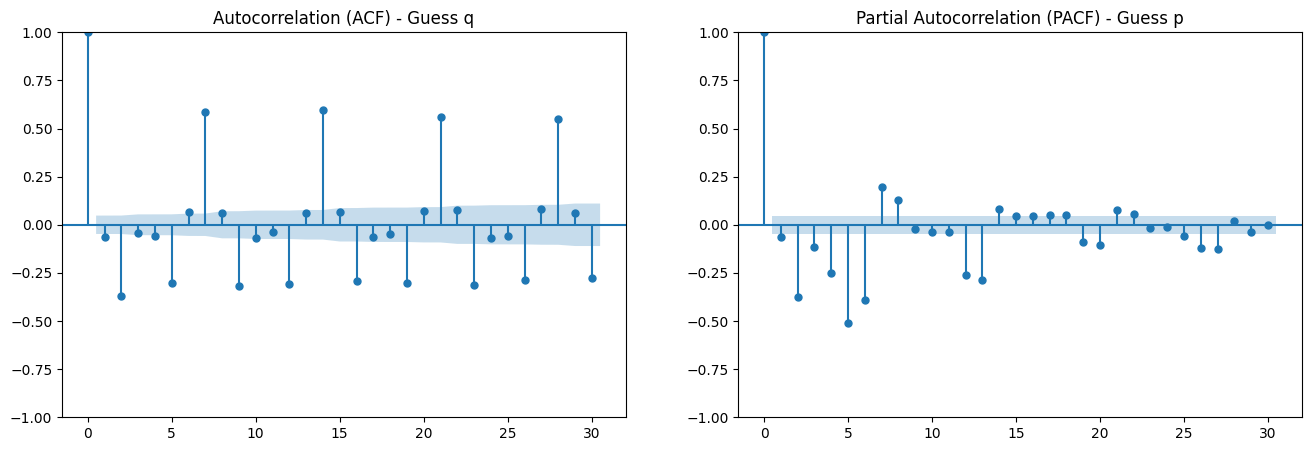

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Left is ACF，right is PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Plot ACF
plot_acf(cleaned_df['sales_diff'], lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF) - Guess q")

# 2. Plot PACF
plot_pacf(cleaned_df['sales_diff'], lags=30, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF) - Guess p")

plt.show()

In [9]:
!pip install pmdarima

import pmdarima as pm

# Automatically find the best p and q
auto_model = pm.auto_arima(cleaned_df['sales'],
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=7, # 7 is a cycle found from the ACF and PACF plots
                           seasonal=True,
                           stationary=False,
                           information_criterion='aic', # According to AIC 
                           trace=False) 
print(auto_model.summary())

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1683
Model:             SARIMAX(3, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -21776.234
Date:                           Wed, 01 Jul 2026   AIC                          43574.468
Time:                                   16:43:30   BIC                          43634.173
Sample:                                        0   HQIC                         43596.583
                                          - 1683                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    852.4891    538.205      1.584      0.113    -20

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/

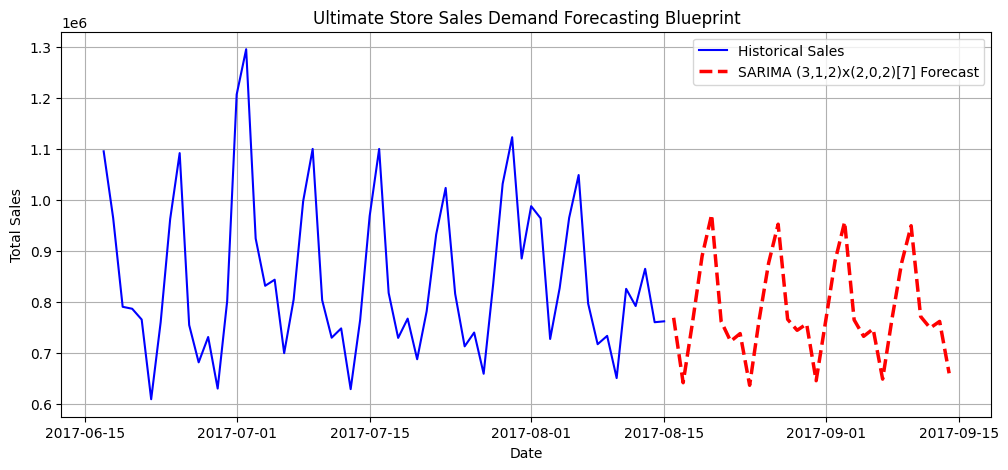

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt

final_model = SARIMAX(cleaned_df['sales'], 
                      order=(3, 1, 2), 
                      seasonal_order=(2, 0, 2, 7),
                      trend='c') # 'c' means constant

# 2. Fit model
final_fitted = final_model.fit(disp=False)

# 3. Forecast the future 30 days
forecast_steps = 30
final_pred = final_fitted.forecast(steps=forecast_steps)

# 4. Plot
plt.figure(figsize=(12, 5))
# Compare with the historical 60-day sales 
plt.plot(cleaned_df.index[-60:], cleaned_df['sales'].iloc[-60:], label='Historical Sales', color='blue')

# Forecast the future 30 days (red dotted line）
future_dates = pd.date_range(start=cleaned_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
plt.plot(future_dates, final_pred, label='SARIMA (3,1,2)x(2,0,2)[7] Forecast', color='red', linestyle='--', linewidth=2.5)

plt.title("Ultimate Store Sales Demand Forecasting Blueprint")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
oil = pd.read_csv('oil.csv')
stores = pd.read_csv('stores.csv')
holidays = pd.read_csv('holidays_events.csv')

# Merge both train and test dataset
df_all = pd.concat([train, test], axis=0, ignore_index=True)
df_all['date'] = pd.to_datetime(df_all['date'])

# 2. Compute rolling mean oil price for 7 days
oil['date'] = pd.to_datetime(oil['date'])
oil = oil.set_index('date').reindex(pd.date_range(df_all['date'].min(), df_all['date'].max())).ffill()
oil = oil.reset_index().rename(columns={'index': 'date'})
oil['oil_roll_mean_7'] = oil['dcoilwtico'].rolling(window=7, min_periods=1).mean()
df_all = df_all.merge(oil[['date', 'oil_roll_mean_7']], on='date', how='left')

# 3. Merge stores information
df_all = df_all.merge(stores, on='store_nbr', how='left')

# 4. Filter and cascade nationwide valid holidays
holidays['date'] = pd.to_datetime(holidays['date'])
# locale == 'National'
national_hols = holidays[(holidays['transferred'] == False) & (holidays['locale'] == 'National')].copy()
national_hols['is_national_holiday'] = 1
national_hols = national_hols.drop_duplicates(subset=['date'])

# Merge all
df_all = df_all.merge(national_hols[['date', 'is_national_holiday']], on='date', how='left')
df_all['is_national_holiday'] = df_all['is_national_holiday'].fillna(0).astype(int)

# 5. Breakdown of timestamp 
df_all['dayofweek'] = df_all['date'].dt.dayofweek
df_all['month'] = df_all['date'].dt.month
df_all['is_weekend'] = df_all['dayofweek'].isin([5, 6]).astype(int)

# 6. Build lag features
df_all = df_all.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
for lag in [16, 17, 23]:
    df_all[f'sales_lag_{lag}'] = df_all.groupby(['store_nbr', 'family'])['sales'].shift(lag)

categorical_cols = ['family', 'city', 'state']
for col in categorical_cols:
    df_all[col] = df_all[col].astype('category')

# 7. Split train and test dataset
train_eng = df_all[df_all['sales'].notna()].copy()
test_eng = df_all[df_all['sales'].isna()].copy()

features = [
    'store_nbr', 'family', 'onpromotion', 'cluster', 'oil_roll_mean_7', 
    'is_national_holiday', 'dayofweek', 'month', 'is_weekend', 'city', 'state',
    'sales_lag_16', 'sales_lag_17', 'sales_lag_23'
]

X_train = train_eng[features]
y_train_log = np.log1p(train_eng['sales'])  # Reduce the skewed distribution of the retail long tail
X_test = test_eng[features]

gbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

gbm.fit(X_train, y_train_log, categorical_feature=categorical_cols)

# 8. Predict and exponentiation
preds_log = gbm.predict(X_test)
final_preds = np.expm1(preds_log)
final_preds = np.clip(final_preds, 0, None)  # Minimum sales is zero

submission = pd.read_csv('sample_submission.csv')
submission['sales'] = final_preds
submission.to_csv('submission.csv', index=False)

print(submission.head())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1395
[LightGBM] [Info] Number of data points in the train set: 3000888, number of used features: 14
[LightGBM] [Info] Start training from score 2.926368
        id     sales
0  3000888  4.121379
1  3000889  5.966369
2  3000890  3.366160
3  3000891  4.853719
4  3000892  4.796900
